In [329]:
import pandas as pd
import numpy as np
import csv
import praw
from prawcore.exceptions import NotFound
from pprint import pprint
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import nltk
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer as SIA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
import gensim
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim import corpora, models
from gensim.utils import simple_preprocess 
from nltk import sent_tokenize
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis
from dash import Dash, dcc, html, Output, Input,State
import dash_bootstrap_components as dbc
import dash
import plotly.graph_objs as go
import base64
import io
import dash_table


# Data Collection

## Load Data Sets

### Kaggele Data Set


In [240]:
"""
 loading Kaggele data sets and cleaning the data 
"""

'\n loading Kaggele data sets and cleaning the data \n'

In [241]:

df= pd.read_csv(r'C:\Users\sarth\Codes\Lbro DS 23ISP492\New folder\salaries.csv')

# Count the number of columns with all NaN values
result_cols=df.isna().all(axis=0).sum()
print ("There are ",result_cols," empty cols")

# Identify columns with all NaN values
empty_columns = [col for col in df.columns if df[col].isna().all()]
print("Empty columns:", empty_columns)

#counting empty cells per col 
empty_cell_count_per_column = df.isnull().sum()
print(empty_cell_count_per_column)


There are  0  empty cols
Empty columns: []
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64


In [242]:
"""
Creating a new CSV file for unique job titles 
"""

'\nCreating a new CSV file for unique job titles \n'

In [243]:
# Extracting unique values from the job_title column
unique_values_title_column = df['job_title'].unique()

# Specifying the file path 
output_file_path = 'unique_values_title_column.csv'

# Write the unique values to a CSV file with header
with open(output_file_path, 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['full_title'])  # Write header
    for value in unique_values_title_column:
        writer.writerow([value])

# Dictionary for job titles to job nature categories
job_nature_categories = {
    "Lead": ["Lead", "Principal", "Head", "Director", "Managing Director", "Manager"],
    "Engineer": ["Engineer", "Architect", "Technician"],
    "Analyst": ["Analyst"],
    "Scientist": ["Scientist"],
    "Consultant": ["Consultant"],
    "Researcher": ["Researcher"],
    "Developer": ["Developer"],
    "Operations": ["Operations", "Ops"],
    "Strategist": ["Strategist"],
    "Administrator": ["Administrator"],
    "Technologist": ["Technologist"],
    "Professional": ["Professional"],
    "Owner": ["Owner"],
    "Associate": ["Associate"],
    "Programmer": ["Programmer"],
    "Biologist": ["Biologist"],
    "Modeler": ["Modeler"],
    "Specialist": ["Specialist"]}
# Reading the original CSV file and create a list of unique job titles
with open(output_file_path, 'r') as file:
    reader = csv.reader(file)
    unique_titles = [row[0] for row in reader]

# Rewriting the CSV file with the corresponding job nature for each title
with open(output_file_path, 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['full_title', 'job_nature'])  
    for title in unique_titles:
        for nature, keywords in job_nature_categories.items():
            if any(keyword.lower() in title.lower() for keyword in keywords):
                writer.writerow([title, nature])
                break  


## Scrapping Reddit Data

In [244]:
"""
loging to Reddit
"""

'\nloging to Reddit\n'

In [245]:
reddit = praw.Reddit(
    client_id='W0UFUAKd4YY0U4KVJigzfA',
    client_secret='LT8UPm_KQhukjTRU2--aBm9ayQNnwg',
    user_agent='DS-app by u/m_Few-Performance515')


In [246]:
"""
For more data, opt to collect data using Reddit search with unique job titles because
subreddit scraping was time-consuming and only yielded ~3000 rows by scrapping 3 subreddit

"""

'\nFor more data, opt to collect data using Reddit search with unique job titles because\nsubreddit scraping was time-consuming and only yielded ~3000 rows by scrapping 3 subreddit\n\n'

In [247]:

keywords = [
    'Data Scientist', 'Data Science Manager', 'Business Intelligence Engineer', 
    'Data Architect', 'Data Analyst', 'ML Engineer', 'Data Modeler', 
    'Machine Learning Engineer', 'Data Integration Specialist', 'Research Scientist',
    'Data Engineer', 'Data Product Manager', 'Data Manager', 'Data Visualization Specialist',
    'Data Specialist', 'Business Intelligence Lead', 'Research Analyst',
    'Business Intelligence Analyst', 'AI Engineer', 'AI Software Engineer',
    'Machine Learning Scientist', 'Data Science Engineer', 'Applied Scientist',
    'Machine Learning Operations Engineer', 'Analytics Engineer', 'Data Management Analyst',
    'Encounter Data Management Professional', 'Data Analytics Specialist', 'Head of Data',
    'Data Analytics Lead', 'Research Engineer', 'AI Scientist',
    'Business Intelligence Developer', 'Machine Learning Developer',
    'Data Management Specialist', 'Data Infrastructure Engineer', 'BI Developer',
    'Admin & Data Analyst', 'Insight Analyst', 'Consultant Data Engineer',
    'Business Intelligence Manager', 'Manager Data Management', 'Data Quality Manager',
    'Data Analytics Manager', 'Robotics Engineer', 'Business Intelligence Specialist',
    'Data Operations Analyst', 'Director of Business Intelligence', 'Data Product Owner',
    'Data Operations Manager', 'AI Research Scientist', 'Data Operations Specialist',
    'Data Science Consultant', 'Data Lead', 'Data Operations Associate', 'AI Architect',
    'Lead Data Scientist', 'MLOps Engineer', 'BI Analyst', 'Applied Research Scientist',
    'Prompt Engineer', 'Data Integration Engineer', 'Machine Learning Infrastructure Engineer',
    'Data Developer', 'CRM Data Analyst', 'ETL Developer', 'Cloud Database Engineer',
    'Data Science Analyst', 'BI Data Analyst', 'Applied Data Scientist', 'Data Quality Engineer',
    'Computational Biologist', 'Big Data Engineer', 'Data Analytics Associate',
    'Data Reporting Analyst', 'Data Management Consultant', 'Data Quality Analyst',
    'Robotics Software Engineer', 'Machine Learning Researcher', 'Data DevOps Engineer',
    'Data Science Director', 'Data Strategist', 'Big Data Developer', 'Quantitative Research Analyst',
    'Lead Machine Learning Engineer', 'Machine Learning Research Engineer', 'Data Analytics Consultant',
    'AI Research Engineer', 'AI Programmer', 'ETL Engineer', 'AI Product Manager', 'AI Developer',
    'Computer Vision Engineer', 'Head of Machine Learning', 'Data Analyst Lead',
    'Data Integration Developer', 'ML Ops Engineer', 'Data Pipeline Engineer', 'Lead Data Analyst',
    'Data Science Lead', 'Director of Data Science', 'Managing Director Data Science',
    'Business Data Analyst', 'NLP Engineer', 'Marketing Data Scientist', 'Deep Learning Engineer',
    'Machine Learning Modeler', 'Decision Scientist', 'Financial Data Analyst', 'Data Strategy Manager',
    'Data Visualization Engineer', 'Azure Data Engineer', 'Principal Data Scientist', 'Staff Data Analyst',
    'Machine Learning Software Engineer', 'Applied Machine Learning Scientist', 'Data Operations Engineer',
    'Machine Learning Manager', 'Principal Machine Learning Engineer', 'Principal Data Engineer',
    'Power BI Developer', 'Head of Data Science', 'Staff Machine Learning Engineer', 'Staff Data Scientist',
    'Machine Learning Specialist', 'Business Intelligence Data Analyst', 'Finance Data Analyst',
    'Software Data Engineer', 'Compliance Data Analyst', 'Cloud Data Engineer', 'Analytics Engineering Manager',
    'AWS Data Architect', 'Product Data Analyst', 'Data Visualization Analyst', 'Autonomous Vehicle Technician',
    'Sales Data Analyst', 'Applied Machine Learning Engineer', 'BI Data Engineer', 'Deep Learning Researcher',
    'Big Data Architect', 'Computer Vision Software Engineer', 'Marketing Data Engineer',
    'Data Science Tech Lead', 'Data Scientist Lead', 'Marketing Data Analyst', 'Principal Data Architect',
    'Data Analytics Engineer', 'Cloud Data Architect', 'Lead Data Engineer', 'Principal Data Analyst'
]

search_limit = None  


with open('reddit_search_results.csv', mode='w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(['Keyword', 'Title', 'URL'])  # header row
    
    for index, keyword in enumerate(keywords):
        try:
            search_results = reddit.subreddit('all').search(keyword, limit=search_limit)
            for submission in search_results:
                writer.writerow([keyword, submission.title, submission.url])
        except NotFound:
            print(f"No results found for keyword: {keyword}")
            continue
        
        
        if index == len(keywords) - 1:
            break


'\nkeywords = [\n    \'Data Scientist\', \'Data Science Manager\', \'Business Intelligence Engineer\', \n    \'Data Architect\', \'Data Analyst\', \'ML Engineer\', \'Data Modeler\', \n    \'Machine Learning Engineer\', \'Data Integration Specialist\', \'Research Scientist\',\n    \'Data Engineer\', \'Data Product Manager\', \'Data Manager\', \'Data Visualization Specialist\',\n    \'Data Specialist\', \'Business Intelligence Lead\', \'Research Analyst\',\n    \'Business Intelligence Analyst\', \'AI Engineer\', \'AI Software Engineer\',\n    \'Machine Learning Scientist\', \'Data Science Engineer\', \'Applied Scientist\',\n    \'Machine Learning Operations Engineer\', \'Analytics Engineer\', \'Data Management Analyst\',\n    \'Encounter Data Management Professional\', \'Data Analytics Specialist\', \'Head of Data\',\n    \'Data Analytics Lead\', \'Research Engineer\', \'AI Scientist\',\n    \'Business Intelligence Developer\', \'Machine Learning Developer\',\n    \'Data Management Speci

### Reddit Data Cleaning

In [248]:
df_Results=pd.read_csv(r"C:\Users\sarth\Codes\Lbro DS 23ISP492\Jupyter\Data_full\reddit_search_results.csv")


In [249]:
# Finding 'not found' results from the scraped Reddit data helps to identify missed keywords (job titles)
filtered_df = df_Results[df_Results['Title'] == "No results found for keyword"]
print(filtered_df)

Empty DataFrame
Columns: [Keyword, Title, URL]
Index: []


In [250]:
# Making a copy of df_1 to avoid changing the original data
df_Results_copy=df_Results.copy()

In [251]:
# Renaming Keyword column heading
df_Results_copy= df_Results_copy.rename(columns={'Keyword': 'job_Title'})

In [252]:
#Droping URL column
df_Results_copy = df_Results_copy.drop(columns= ['URL'])

print(df_Results_copy.head())


        job_Title                                              Title
0  Data Scientist  125k offer as a data scientist but I have no i...
1  Data Scientist  Roadmap to become a data scientist? And is it ...
2  Data Scientist        I don't want to be a Data Scientist Anymore
3  Data Scientist                          Nyuddannet data scientist
4  Data Scientist  What kind of Data Scientist is in demand for 2...


In [253]:
df_unique=pd.read_csv(r"C:\Users\sarth\Codes\Lbro DS 23ISP492\Jupyter\Data_full\unique_values_title_column.csv")
df_unique= df_unique.rename(columns={'full_title': 'job_Title'})

df_merge=pd.merge(df_Results_copy,df_unique,on='job_Title', how='inner')
print(df_merge.head())



        job_Title                                              Title  \
0  Data Scientist  125k offer as a data scientist but I have no i...   
1  Data Scientist  Roadmap to become a data scientist? And is it ...   
2  Data Scientist        I don't want to be a Data Scientist Anymore   
3  Data Scientist                          Nyuddannet data scientist   
4  Data Scientist  What kind of Data Scientist is in demand for 2...   

  job_nature  
0  Scientist  
1  Scientist  
2  Scientist  
3  Scientist  
4  Scientist  


In [254]:
# Merging the Reddit scraped data with unique job titles and job nature
df_merge.to_csv('merge_data.csv', header=['job_Title','Title','job_nature'], encoding='utf-8', index=False)

# Data Analysis

## Reddit Data Analysis

In [255]:
df_merge = pd.read_csv(r"C:\Users\sarth\Codes\DS_Final_Code\merge_data.csv")
print(df_merge.head())

        job_Title                                              Title  \
0  Data Scientist  125k offer as a data scientist but I have no i...   
1  Data Scientist  Roadmap to become a data scientist? And is it ...   
2  Data Scientist        I don't want to be a Data Scientist Anymore   
3  Data Scientist                          Nyuddannet data scientist   
4  Data Scientist  What kind of Data Scientist is in demand for 2...   

  job_nature  
0  Scientist  
1  Scientist  
2  Scientist  
3  Scientist  
4  Scientist  


In [256]:
sia = SIA()

# Analyzing the sentiment for each post
results = []
for title in df_merge['Title']:
    pol_score = sia.polarity_scores(title)
    pol_score['title'] = title
    results.append(pol_score)


sentiment_df = pd.DataFrame(results)

# Merge the sentiment analysis results with df_merge
df_merge= pd.concat([df_merge, sentiment_df], axis=1)

# Rename columns for clarity
df_merge.rename(columns={'compound': 'Title_Compound_Score',
                   'neg': 'Title_Negative_Score',
                   'neu': 'Title_Neutral_Score',
                   'pos': 'Title_Positive_Score'}, inplace=True)


In [257]:
df_merge= df_merge.iloc[:, :7]


In [258]:
df_merge.head()

,job_Title,Title,job_nature,Title_Negative_Score,Title_Neutral_Score,Title_Positive_Score,Title_Compound_Score
0,Data Scientist,125k offer as a data scientist but I have no i...,Scientist,0.157,0.843,0.0,-0.4215
1,Data Scientist,Roadmap to become a data scientist? And is it ...,Scientist,0.077,0.923,0.0,-0.1926
2,Data Scientist,I don't want to be a Data Scientist Anymore,Scientist,0.133,0.867,0.0,-0.0572
3,Data Scientist,Nyuddannet data scientist,Scientist,0.000,1.000,0.0,0.0000
4,Data Scientist,What kind of Data Scientist is in demand for 2...,Scientist,0.143,0.857,0.0,-0.1280


In [259]:
df_merge.to_csv('merge_data_SIA.csv', encoding='utf-8', index=False)


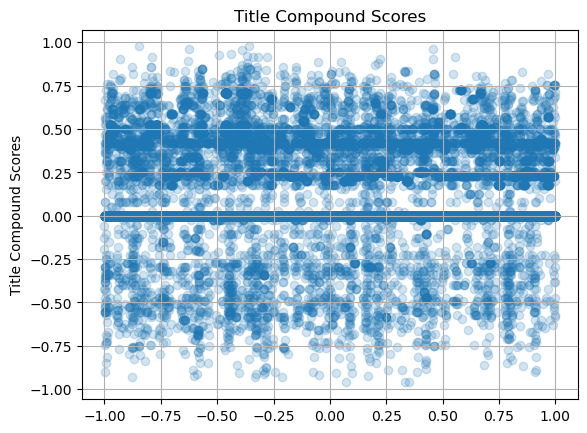

In [260]:
threshold_values = np.linspace(-1, 1, len(df_merge['Title_Compound_Score']))


plt.scatter(threshold_values, df_merge['Title_Compound_Score'], marker='o', alpha=0.2)

plt.ylabel('Title Compound Scores')
plt.title('Title Compound Scores')
plt.grid(True)
plt.show()

In [261]:
df_merge_SIA = pd.read_csv(r"C:\Users\sarth\Codes\DS_Final_Code\merge_data_SIA.csv")

In [262]:
df_merge_SIA.loc[df_merge_SIA['Title_Compound_Score'] >= 0.05, 'label'] = 1
df_merge_SIA.loc[df_merge_SIA['Title_Compound_Score'] <= -0.05, 'label'] = -1
df_merge_SIA.loc[(df_merge_SIA['Title_Compound_Score'] > -0.05) & 
                 (df_merge_SIA['Title_Compound_Score'] < 0.05), 'label'] = 0

print(df_merge_SIA.head())

        job_Title                                              Title  \
0  Data Scientist  125k offer as a data scientist but I have no i...   
1  Data Scientist  Roadmap to become a data scientist? And is it ...   
2  Data Scientist        I don't want to be a Data Scientist Anymore   
3  Data Scientist                          Nyuddannet data scientist   
4  Data Scientist  What kind of Data Scientist is in demand for 2...   

  job_nature  Title_Negative_Score  Title_Neutral_Score  Title_Positive_Score  \
0  Scientist                 0.157                0.843                   0.0   
1  Scientist                 0.077                0.923                   0.0   
2  Scientist                 0.133                0.867                   0.0   
3  Scientist                 0.000                1.000                   0.0   
4  Scientist                 0.143                0.857                   0.0   

   Title_Compound_Score  label  
0               -0.4215   -1.0  
1             

In [263]:
df_merge_SIA.label.value_counts()

label
 0.0    25429
 1.0     9189
-1.0     2229
Name: count, dtype: int64

In [264]:
df_merge_SIA.to_csv('merge_data_SIA_label.csv', encoding='utf-8', index=False)

In [265]:
merge_data_SIA_label=pd.read_csv(r"C:\Users\sarth\Codes\DS_Final_Code\merge_data_SIA_label.csv")

In [266]:
print("positive nature':\n") 
print(merge_data_SIA_label.loc[merge_data_SIA_label['label'] == 0, 'job_nature'])

positive nature':

3        Scientist
6        Scientist
7        Scientist
9        Scientist
10       Scientist
           ...    
36839         Lead
36841         Lead
36844         Lead
36845         Lead
36846         Lead
Name: job_nature, Length: 25429, dtype: object


In [267]:
# Group by job_Title, and label calculate percentage
grouped = merge_data_SIA_label.groupby([ 'job_Title'])['label'].value_counts(normalize=True) * 100

# label values as columns
grouped = grouped.unstack('label', fill_value=0)


grouped.reset_index(inplace=True)

# Rename the columns for better clarity
grouped.columns.name = None  # Remove the name of the index
grouped.rename(columns={0.0: 'Neutral', 1.0: 'Positive', -1.0: 'Negative'}, inplace=True)

grouped.head()

,job_Title,Negative,Neutral,Positive
0,AI Architect,2.016129,60.887097,37.096774
1,AI Developer,16.182573,63.900415,19.917012
2,AI Engineer,8.571429,80.408163,11.020408
3,AI Product Manager,8.835341,67.469880,23.694779
4,AI Programmer,11.111111,71.604938,17.283951


In [268]:
# Save the result to CSV file
grouped.to_csv('grouped_SIA.csv', encoding='utf-8', index=False)

## Kaggle and Reddit Data Sets merging 

In [269]:
grouped_SIA = pd.read_csv(r'C:\Users\sarth\Codes\DS_Final_Code\grouped_SIA.csv')
grouped_SIA.head()



,job_Title,Negative,Neutral,Positive
0,AI Architect,2.016129,60.887097,37.096774
1,AI Developer,16.182573,63.900415,19.917012
2,AI Engineer,8.571429,80.408163,11.020408
3,AI Product Manager,8.835341,67.469880,23.694779
4,AI Programmer,11.111111,71.604938,17.283951


In [270]:
grouped_SIA= grouped_SIA.rename(columns={'job_Title': 'job_title'})
grouped_SIA.head()

,job_title,Negative,Neutral,Positive
0,AI Architect,2.016129,60.887097,37.096774
1,AI Developer,16.182573,63.900415,19.917012
2,AI Engineer,8.571429,80.408163,11.020408
3,AI Product Manager,8.835341,67.469880,23.694779
4,AI Programmer,11.111111,71.604938,17.283951


In [271]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,MI,FT,Data Scientist,120000,USD,120000,AU,0,AU,S
1,2024,MI,FT,Data Scientist,70000,USD,70000,AU,0,AU,S
2,2024,MI,CT,Data Scientist,130000,USD,130000,US,0,US,M
3,2024,MI,CT,Data Scientist,110000,USD,110000,US,0,US,M
4,2024,MI,FT,Data Science Manager,240000,USD,240000,US,0,US,M


In [272]:
df = df.drop(columns=['employment_type', 'salary_currency', 'salary', 'remote_ratio', 'employee_residence',
                              'experience_level', 'company_location', 'company_size'])

In [273]:

df=df.rename(columns={'salary_in_usd': 'salary'})
df.head()


,work_year,job_title,salary
0,2024,Data Scientist,120000
1,2024,Data Scientist,70000
2,2024,Data Scientist,130000
3,2024,Data Scientist,110000
4,2024,Data Science Manager,240000


In [274]:
# Merge datasets of reddit and kaggle
merge_df_main= pd.merge(grouped_SIA, df, on='job_title', how='inner')
merge_df_main.head()

,job_title,Negative,Neutral,Positive,work_year,salary
0,AI Architect,2.016129,60.887097,37.096774,2022,180000
1,AI Architect,2.016129,60.887097,37.096774,2024,285000
2,AI Architect,2.016129,60.887097,37.096774,2024,153400
3,AI Architect,2.016129,60.887097,37.096774,2024,449000
4,AI Architect,2.016129,60.887097,37.096774,2024,173000


In [275]:
# final merging with all needed data sets
unique_values_title_column=pd.read_csv(r"C:\Users\sarth\Codes\DS_Final_Code\unique_values_title_column.csv")

 

In [276]:
unique_values_title_column=unique_values_title_column.rename(columns={'full_title':'job_title'})


In [277]:
merge_final = pd.merge(merge_df_main, unique_values_title_column,on='job_title', how='inner')
merge_final.head()

,job_title,Negative,Neutral,Positive,work_year,salary,job_nature
0,AI Architect,2.016129,60.887097,37.096774,2022,180000,Engineer
1,AI Architect,2.016129,60.887097,37.096774,2024,285000,Engineer
2,AI Architect,2.016129,60.887097,37.096774,2024,153400,Engineer
3,AI Architect,2.016129,60.887097,37.096774,2024,449000,Engineer
4,AI Architect,2.016129,60.887097,37.096774,2024,173000,Engineer


In [278]:
merge_final.to_csv('merge_final.csv', encoding='utf-8', index=False)

# Exploratory Data Analysis

## Correlation

In [279]:
# checking dtype
print(merge_df_main.dtypes)

job_title     object
Negative     float64
Neutral      float64
Positive     float64
work_year      int64
salary         int64
dtype: object


In [280]:
numerical_cols = ['Negative', 'Positive', 'Neutral', 'salary']
categorical_cols= ['job_title' ]

In [281]:
# Standardize numerical features
scaler = StandardScaler()
merge_df_main[numerical_cols] = scaler.fit_transform(merge_df_main[numerical_cols])

In [282]:
 #Encode categorical columns
ohe = OneHotEncoder(sparse_output=False, drop='first')
encoded_categorical = ohe.fit_transform(merge_df_main[categorical_cols])
encoded_df = pd.DataFrame(encoded_categorical, columns=ohe.get_feature_names_out(categorical_cols))

# Concatenate the encoded categorical columns with the numerical columns
combined_df = pd.concat([merge_df_main[numerical_cols], encoded_df], axis=1)


In [283]:
combined_df.head()

,Negative,Positive,Neutral,salary,job_title_AI Developer,job_title_AI Engineer,job_title_AI Product Manager,job_title_AI Programmer,job_title_AI Research Engineer,job_title_AI Research Scientist,...,job_title_Research Analyst,job_title_Research Engineer,job_title_Research Scientist,job_title_Robotics Engineer,job_title_Robotics Software Engineer,job_title_Sales Data Analyst,job_title_Software Data Engineer,job_title_Staff Data Analyst,job_title_Staff Data Scientist,job_title_Staff Machine Learning Engineer
0,-1.185578,1.143507,-0.584634,0.444217,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-1.185578,1.143507,-0.584634,1.976114,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1.185578,1.143507,-0.584634,0.056136,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-1.185578,1.143507,-0.584634,4.368791,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-1.185578,1.143507,-0.584634,0.342090,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [284]:
# Calculate the correlation matrix
correlation = combined_df.corr()

for num_col in numerical_cols:
    print(f"Correlation of {num_col} with categorical columns:")
    print(correlation[num_col].sort_values(ascending=False), '\n')

correlation.to_csv('correlation.csv', encoding='utf-8', index=False)

Correlation of Negative with categorical columns:
Negative                               1.000000
job_title_Data Scientist               0.807291
job_title_Research Scientist           0.217156
job_title_AI Scientist                 0.075682
job_title_Decision Scientist           0.054808
                                         ...   
job_title_Analytics Engineer          -0.205875
job_title_Applied Scientist           -0.215590
job_title_Data Architect              -0.233675
Neutral                               -0.298060
job_title_Machine Learning Engineer   -0.333314
Name: Negative, Length: 153, dtype: float64 

Correlation of Positive with categorical columns:
Positive                                     1.000000
job_title_Business Intelligence Engineer     0.629963
job_title_Business Intelligence Analyst      0.546432
job_title_Business Intelligence Developer    0.289798
job_title_Computer Vision Engineer           0.205676
                                               ...   
jo

In [285]:

top_correlated = correlation['salary'].abs().nlargest(16).index.tolist()
top_correlated.remove('salary')

top_correlation_values = correlation.loc[top_correlated, 'salary'].sort_values(ascending=False)
print("Top 15 variables most correlated with salary:")
print(top_correlation_values.head(16))

Top 15 variables most correlated with salary:
job_title_Machine Learning Engineer        0.196096
job_title_Research Scientist               0.114158
job_title_Applied Scientist                0.098171
Neutral                                    0.092752
job_title_Research Engineer                0.082487
job_title_ML Engineer                      0.071569
job_title_Data Science Manager             0.056606
job_title_Head of Data                     0.056052
job_title_Machine Learning Scientist       0.054966
job_title_BI Developer                    -0.048167
job_title_Business Intelligence Analyst   -0.056718
job_title_Data Specialist                 -0.062396
job_title_Data Manager                    -0.068599
Positive                                  -0.080483
job_title_Data Analyst                    -0.255916
Name: salary, dtype: float64


In [286]:
correlated_dash = correlation['salary'].abs().index.tolist()
correlated_dash.remove('salary')

dash_value = correlation.loc[correlated_dash, 'salary'].sort_values(ascending=False)

dash_value_df = dash_value.reset_index()



dash_value_df.to_csv('dash_value.csv', encoding='utf-8', index=False)



In [287]:
correlation_2= merge_df_main[['Positive','Negative', 'Neutral', 'salary']].corr().sort_values(by='salary', ascending=False)


correlation_2.head()

,Positive,Negative,Neutral,salary
salary,-0.080483,-0.034562,0.092752,1.000000
Neutral,-0.901530,-0.298060,1.000000,0.092752
Negative,-0.144339,1.000000,-0.298060,-0.034562
Positive,1.000000,-0.144339,-0.901530,-0.080483


## Heatmap

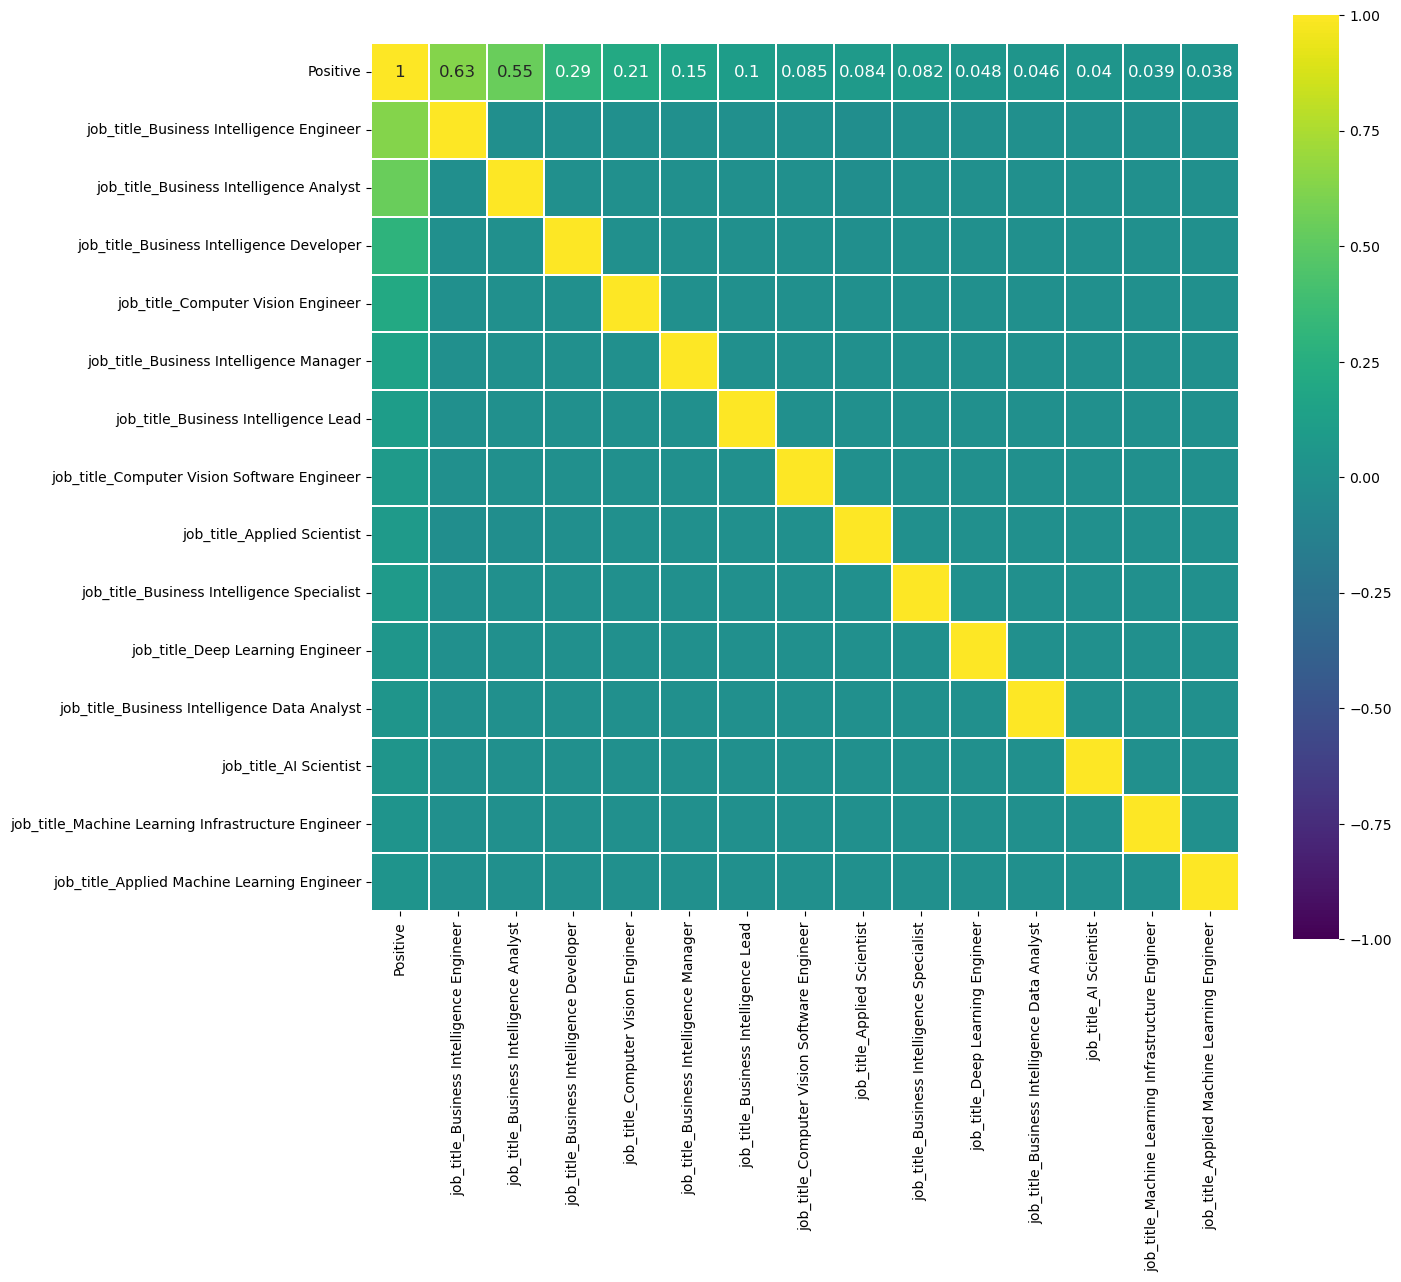

In [327]:
'''
possible set of Heatmap :{Positive,Negative,Neutral,salary}
from coorelation_2 identified strong correlation among positive and neutral 
'''
k = 15
Columns='Positive'
Row='Negative'
cols = correlation.nlargest(15,Columns)[Row].index
cm = np.corrcoef(combined_df[cols].values.T)

f, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, vmin=-1, vmax=1, linewidths=0.01, square=True, annot=True, cmap='viridis',
            linecolor='white', xticklabels=cols.values,annot_kws={'size':12}, yticklabels=cols.values)
plt.show()



## Grouped Bar Chart

C:\Users\sarth\AppData\Local\Temp\ipykernel_720\3278519404.py:8: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.


C:\Users\sarth\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead

C:\Users\sarth\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead

C:\Users\sarth\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead

C:\Users\sarth\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype

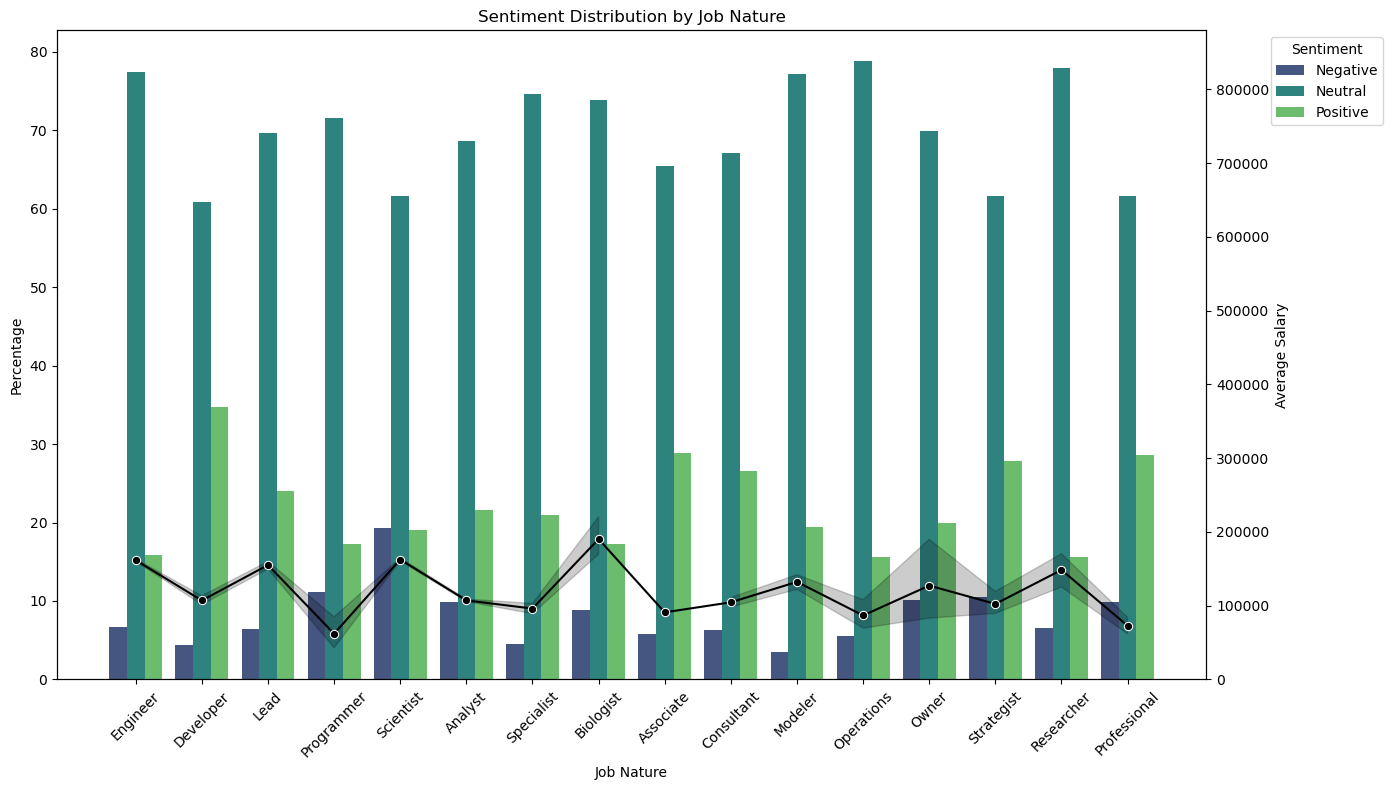

In [322]:
# melting
sentiments = ['Negative', 'Neutral', 'Positive']
data_melted = merge_final.melt(id_vars=['job_nature'], value_vars=sentiments, var_name='Sentiment', value_name='Percentage')


fig, ax1 = plt.subplots(figsize=(14, 8))

sns.barplot(x='job_nature', y='Percentage', hue='Sentiment', data=data_melted,ci=None, palette='viridis', ax=ax1)

ax1.set_title('Sentiment Distribution by Job Nature')
ax1.set_xlabel('Job Nature')
ax1.set_ylabel('Percentage')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
ax1.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')


ax2 = ax1.twinx()
sns.lineplot(x='job_nature', y='salary', data=merge_final, color='black', marker='o', ax=ax2)

ax2.set_ylabel('Average Salary')
ax2.set_ylim(0, merge_final['salary'].max() * 1.1)


plt.tight_layout()
plt.show()


# Grouping by average 

In [290]:
grouped_salary = merge_final.groupby(['job_nature'])['salary'].agg(mean_salary='mean').reset_index()
grouped_salary.head()

,job_nature,mean_salary
0,Analyst,107227.347472
1,Associate,91000.000000
2,Biologist,190384.250000
3,Consultant,104636.086022
4,Developer,107101.008333


In [291]:
grouped_setiment= merge_final.groupby(['job_nature'])['Positive'].agg(Positive_mean='mean').reset_index()
grouped_setiment_2= merge_final.groupby(['job_nature'])['Negative'].agg(Negative_mean='mean').reset_index()
grouped_setiment_3= merge_final.groupby(['job_nature'])['Neutral'].agg(Neutral_mean='mean').reset_index()


In [292]:

merged_bin_1= pd.merge(grouped_setiment, grouped_setiment_2, on='job_nature', how='inner')
merged_bin_2= pd.merge(merged_bin_1, grouped_setiment_3, on='job_nature', how='inner')


In [293]:
grouped=pd.merge(merged_bin_2, grouped_salary, on='job_nature', how='inner')
grouped.head(20)
grouped.to_csv('grouped.csv', encoding='utf-8', index=False)

##  Topic modelling

In [295]:
# SIA labeld data set is using for the topic modelling
df_merge_SIA.head()

,job_Title,Title,job_nature,Title_Negative_Score,Title_Neutral_Score,Title_Positive_Score,Title_Compound_Score,label
0,Data Scientist,125k offer as a data scientist but I have no i...,Scientist,0.157,0.843,0.0,-0.4215,-1.0
1,Data Scientist,Roadmap to become a data scientist? And is it ...,Scientist,0.077,0.923,0.0,-0.1926,-1.0
2,Data Scientist,I don't want to be a Data Scientist Anymore,Scientist,0.133,0.867,0.0,-0.0572,-1.0
3,Data Scientist,Nyuddannet data scientist,Scientist,0.000,1.000,0.0,0.0000,0.0
4,Data Scientist,What kind of Data Scientist is in demand for 2...,Scientist,0.143,0.857,0.0,-0.1280,-1.0


## Topic modelling for neutral sentiments


In [296]:
topic_neu= df_merge_SIA[df_merge_SIA['label'] == 0][['Title']].reset_index(drop=True)
topic_neu

,Title
0,Nyuddannet data scientist
1,I am a Senior Data Scientist. Ask me questions...
2,Ok....wtf is a data scientist?
3,"People in data science, how is it?"
4,Data scientist quits her job at Spotify
...,...
25424,What Projects Did You Have On Your Portfolio W...
25425,Business Analyst vs Data Analyst
25426,OE for data analysts- Private group
25427,[Hiring] Principal Data Analyst


In [297]:
#topic_neu.to_csv('topic_neu.txt', sep=',', index=False, header=False)
topic_neu.to_csv('titles.txt', sep=' ', index=False, header=False)

In [298]:

with open(r"C:\Users\sarth\Codes\DS_Final_Code\topic_neu.txt", "r", encoding="utf-8") as corpus:
     data = corpus.readlines()


data


["I don't want to be a Data Scientist Anymore\n",
 'Nyuddannet data scientist\n',
 'What kind of Data Scientist is in demand for 2024?\n',
 '"I am a Senior Data Scientist. Ask me questions that you have related to Data Science, AI"\n',
 'Ok....wtf is a data scientist?\n',
 '"People in data science, how is it?"\n',
 'Data scientist quits her job at Spotify\n',
 "I'm a Full-Stack Data Scientist\n",
 'Anon is a Data Scientist\n',
 "Brazilian data scientist analyses thousands of games and finds Niemann's approximate rating.\n",
 '"If you mainly want to do Machine Learning, don\'t become a Data Scientist"\n',
 'Data Scientist: job preparation guide 2024\n',
 'Job hunt results as a mid-level Data Scientist w/ ADHD\n',
 'Data Scientist salary in EU [2023] Thread\n',
 'Reddit Hiring Sr Data Scientist\n',
 'Where are the Junior Level Data Scientist Jobs?\n',
 'Guys Only Need Apply: Data Scientist Position\n',
 'Shout Out to All the Mediocre Data Scientists Out There\n',
 'What is the difference

## Topic modelling for neutral sentiments

In [299]:
stop_words = stopwords.words('english')



def sent_to_words(sentences):
    for sentence in sentences:
        yield(gensim.utils.simple_preprocess(sentence, deacc=True))  # deacc=True removes punctuations


data_words = list(sent_to_words(data))


bigram = gensim.models.Phrases(data_words, min_count=5, threshold=100)
trigram = gensim.models.Phrases(bigram[data_words], threshold=100)


bigram_mod = gensim.models.phrases.Phraser(bigram)
trigram_mod = gensim.models.phrases.Phraser(trigram)


def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc)) if word not in stop_words] for doc in texts]

def make_bigrams(texts):
    return [bigram_mod[doc] for doc in texts]

def make_trigrams(texts):
    return [trigram_mod[bigram_mod[doc]] for doc in texts]


data_words_nostops = remove_stopwords(data_words)

data_words_bigrams = make_bigrams(data_words_nostops)


print(data_words_bigrams[:1])


id2word = corpora.Dictionary(data_words_bigrams)


corpus = [id2word.doc2bow(text) for text in data_words_bigrams]


lda_model = models.LdaModel(corpus, num_topics=2, id2word=id2word, passes=15)


topics = lda_model.print_topics(num_words=10)
for topic in topics:
    print(topic)


pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda_model, corpus, id2word)
pyLDAvis.display(vis)


[['want', 'data', 'scientist', 'anymore']]
(0, '0.087*"learning" + 0.076*"hiring" + 0.071*"machine" + 0.058*"engineer" + 0.051*"python" + 0.027*"usd" + 0.026*"sql" + 0.020*"ca" + 0.018*"remote" + 0.017*"san"')
(1, '0.151*"data" + 0.083*"hiring" + 0.046*"analyst" + 0.032*"remote" + 0.023*"engineer" + 0.018*"science" + 0.017*"lead" + 0.017*"analytics" + 0.015*"sql" + 0.014*"architect"')


## Topic modeling for positive sentiments

In [300]:
topic_pos= df_merge_SIA[df_merge_SIA['label'] == 1][['Title']].reset_index(drop=True)
topic_pos

,Title
0,Ousted Florida data scientist Rebekah Jones wi...
1,"Like, Every time, ever. When the DevOps Engine..."
2,21 y.o Data Scientist & Digital Analyst from T...
3,"If you mainly want to do Machine Learning, don..."
4,£19.91/hr for a PhD Data scientist 😭😂😂
...,...
9184,"Data Analyst, fine gentleman teleworking at th..."
9185,Fidelity is hiring a Principal Data Analyst wi...
9186,Data Analyst Resume Help
9187,DataAnalyst.com - I launched a niche job board...


In [301]:
topic_pos.to_csv('titles_pos.txt', sep=' ', index=False, header=False)

In [302]:
with open(r"C:\Users\sarth\Codes\DS_Final_Code\titles_pos.txt", "r", encoding="utf-8") as corpus_pos:
     data_pos = corpus_pos.readlines()


data_pos

['"Ousted Florida data scientist Rebekah Jones wins House primary, will face Rep. Matt Gaetz"\n',
 '"Like, Every time, ever. When the DevOps Engineer chats with the Data Scientist."\n',
 '"21 y.o Data Scientist & Digital Analyst from Turkey. Give me your best, Reddit!"\n',
 '"If you mainly want to do Machine Learning, don\'t become a Data Scientist"\n',
 '"£19.91/hr for a PhD Data scientist 😭😂😂"\n',
 '"Got promoted to Data Scientist after 1.5 years  [50 chars]                        "\n',
 '"Prove you\'re a ""real"" data scientist in one sentence."\n',
 '"Florida police were after a covid-19 data scientist. She turned herself in — and tested positive."\n',
 '"What does a PIP look like for data scientists?"\n',
 '"Why are Data lakes ideal for Data Scientists over Data Warehouses?"\n',
 '"Future Data Scientist 🥳"\n',
 '"Manchester United hire Southampton\'s Lead Data Scientist"\n',
 '"[D] Data scientists who made a passive income, what did you do?"\n',
 '"Hi! We are Dr. Amanda Martin and

In [323]:

stop_words = stopwords.words('english')



def sent_to_words(sentences):
    for sentence in sentences:
        yield(gensim.utils.simple_preprocess(sentence, deacc=True))  # deacc=True removes punctuations


data_words = list(sent_to_words(data_pos))


bigram = gensim.models.Phrases(data_words, min_count=5, threshold=100)
trigram = gensim.models.Phrases(bigram[data_words], threshold=100)


bigram_mod = gensim.models.phrases.Phraser(bigram)
trigram_mod = gensim.models.phrases.Phraser(trigram)


def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc)) if word not in stop_words] for doc in texts]

def make_bigrams(texts):
    return [bigram_mod[doc] for doc in texts]

def make_trigrams(texts):
    return [trigram_mod[bigram_mod[doc]] for doc in texts]


data_words_nostops = remove_stopwords(data_words)


data_words_bigrams = make_bigrams(data_words_nostops)


print(data_words_bigrams[:1])


id2word = corpora.Dictionary(data_words_bigrams)
corpus = [id2word.doc2bow(text) for text in data_words_bigrams]


lda_model = models.LdaModel(corpus, num_topics=2, id2word=id2word, passes=15)


topics = lda_model.print_topics(num_words=10)
for topic in topics:
    print(topic)


pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda_model, corpus, id2word)
pyLDAvis.display(vis)

[['ousted_florida', 'data', 'scientist', 'rebekah_jones', 'wins_house', 'primary', 'face_rep', 'matt_gaetz']]
(0, '0.082*"data" + 0.032*"hiring" + 0.032*"analyst" + 0.026*"intelligence" + 0.026*"business" + 0.021*"united" + 0.018*"ai" + 0.018*"remote" + 0.016*"states" + 0.012*"science"')
(1, '0.070*"hiring" + 0.058*"learning" + 0.050*"engineer" + 0.044*"machine" + 0.034*"data" + 0.032*"python" + 0.027*"spark" + 0.023*"usd" + 0.021*"sql" + 0.021*"ca"')


# Topic modeling for negative sentiments

In [304]:
topic_neg= df_merge_SIA[df_merge_SIA['label'] == -1][['Title']].reset_index(drop=True)
topic_neg

,Title
0,125k offer as a data scientist but I have no i...
1,Roadmap to become a data scientist? And is it ...
2,I don't want to be a Data Scientist Anymore
3,What kind of Data Scientist is in demand for 2...
4,Do any of you regret becoming a Data Scientist?
...,...
2224,"📢 Gartner is hiring a Sr Principal Analyst, Da..."
2225,Poor little data analysts
2226,Will being data analyst in casino resort ruin ...
2227,"""Data Analyst"" is a scam?"


In [305]:
topic_neg.to_csv('titles_neg.txt', sep=' ', index=False, header=False)

In [306]:
with open(r"C:\Users\sarth\Codes\DS_Final_Code\titles_neg.txt", "r", encoding="utf-8") as corpus_pos:
     data_neg = corpus_pos.readlines()


data_neg

['"125k offer as a data scientist but I have no idea what a data scientist does"\n',
 '"Roadmap to become a data scientist? And is it hard to get a data analyst or data scientist job in India ?"\n',
 '"I don\'t want to be a Data Scientist Anymore"\n',
 '"What kind of Data Scientist is in demand for 2024?"\n',
 '"Do any of you regret becoming a Data Scientist?"\n',
 '"What would you say the hardest thing in data science, that most people (who aspire to be a data scientist) ignore?"\n',
 '"Agents raid home of fired Florida data scientist who built COVID-19 dashboard"\n',
 '"DeSantis appointee quits after raid on home of fired Florida data scientist"\n',
 '"Fired Florida COVID data scientist to challenge Gaetz for U.S. House seat"\n',
 '"Stop asking data scientist riddles in interviews!"\n',
 '"Offend a data scientist in one tweet"\n',
 '"Data Scientist Rebekah Jones, Facing Arrest, Turns Herself In To Florida Authorities"\n',
 '"Florida fired its coronavirus data scientist. Now she’s pub

In [307]:

stop_words = stopwords.words('english')



def sent_to_words(sentences):
    for sentence in sentences:
        yield(gensim.utils.simple_preprocess(sentence, deacc=True))  # deacc=True removes punctuations


data_words = list(sent_to_words(data_neg))


bigram = gensim.models.Phrases(data_words, min_count=5, threshold=100)
trigram = gensim.models.Phrases(bigram[data_words], threshold=100)


bigram_mod = gensim.models.phrases.Phraser(bigram)
trigram_mod = gensim.models.phrases.Phraser(trigram)


def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc)) if word not in stop_words] for doc in texts]

def make_bigrams(texts):
    return [bigram_mod[doc] for doc in texts]

def make_trigrams(texts):
    return [trigram_mod[bigram_mod[doc]] for doc in texts]


data_words_nostops = remove_stopwords(data_words)


data_words_bigrams = make_bigrams(data_words_nostops)


print(data_words_bigrams[:1])


id2word = corpora.Dictionary(data_words_bigrams)


corpus = [id2word.doc2bow(text) for text in data_words_bigrams]


lda_model = models.LdaModel(corpus, num_topics=2, id2word=id2word, passes=15)


topics = lda_model.print_topics(num_words=10)
for topic in topics:
    print(topic)


pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda_model, corpus, id2word)
pyLDAvis.display(vis)

[['offer', 'data', 'scientist', 'idea', 'data', 'scientist']]
(0, '0.060*"data" + 0.030*"analyst" + 0.013*"learning" + 0.012*"hiring" + 0.009*"science" + 0.008*"deep" + 0.007*"machine" + 0.007*"sales" + 0.007*"research" + 0.006*"manager"')
(1, '0.067*"data" + 0.024*"scientist" + 0.017*"engineer" + 0.013*"ai" + 0.012*"fired" + 0.010*"florida" + 0.008*"analysts" + 0.007*"scientists" + 0.007*"software" + 0.006*"autonomous_vehicles"')


# Dashboard

In [309]:
app = Dash(__name__, external_stylesheets=[dbc.themes.BOOTSTRAP])

In [310]:
dataset_location = r"C:\Users\sarth\Codes\DS_Final_Code\dash_value.csv"
df = pd.read_csv(dataset_location)

In [311]:
app = dash.Dash(__name__)

app.layout = html.Div([
    dcc.Tabs(id="tabs", children=[
        dcc.Tab(label='Dashboard', children=[
            html.Div([
                # Left side: Heatmap and Table
                html.Div([
                    # Heatmap
                    html.Div([
                        html.H3("Correaltion"),
                        dcc.Graph(id='heatmap', figure=create_heatmap(correlation_2), style={'height': '300px'})
                    ], style={'width': '100%', 'display': 'block'}),
                    
                    # Table
                    html.Div([
                        html.H3("Veriables Correlation with Salary"),
                        dash_table.DataTable(
                            id='table',
                            columns=[{"name": i, "id": i} for i in dash_value_df.columns],
                            data=dash_value_df.to_dict('records'),
                            page_size=10,
                            style_table={'height': '300px', 'overflowY': 'auto'}
                        )
                    ], style={'width': '100%', 'display': 'block'})
                ], style={'width': '30%', 'display': 'inline-block', 'vertical-align': 'top'}),
                
                # Right side: Grouped Bar Chart
                html.Div([
                    html.H2("Grouped Bar Chart"),
                    dcc.Graph(id='grouped-bar-chart', style={'width': '100%', 'height': '90vh'})
                ], style={'width': '70%', 'display': 'inline-block', 'vertical-align': 'top'})
            ])
        ])
    ])
])

In [312]:

@app.callback(
    Output('grouped-bar-chart', 'figure'),
    [Input('tabs', 'value')]  # Use any input that triggers the update
)
def update_grouped_bar_chart(_):
    
    dataset_location = r"C:\Users\sarth\Codes\DS_Final_Code\grouped.csv"
    
    
    df = pd.read_csv(dataset_location)

    # Create the figure
    fig = go.Figure()

    # Add bar traces for each sentiment
    fig.add_trace(go.Bar(
        x=df['job_nature'],
        y=df['Negative_mean'],
        name='Negative',
        marker_color='indianred'
    ))

    fig.add_trace(go.Bar(
        x=df['job_nature'],
        y=df['Neutral_mean'],
        name='Neutral',
        marker_color='lightsalmon'
    ))

    fig.add_trace(go.Bar(
        x=df['job_nature'],
        y=df['Positive_mean'],
        name='Positive',
        marker_color='lightgreen'
    ))

  
    fig.add_trace(go.Scatter(
        x=df['job_nature'],
        y=df['mean_salary'],
        mode='lines+markers',
        name='Average Salary',
        yaxis='y2',
        line=dict(color='black'),
        marker=dict(color='black')
    ))

   
    fig.update_layout(
        barmode='group',
        title='Average Sentiments Percentage and Average Salary by Job Nature',
        xaxis_title='Job Nature',
        yaxis=dict(
            title='Percentage',
            titlefont=dict(
                color='#1f77b4'
            ),
            tickfont=dict(
                color='#1f77b4'
            )
        ),
        yaxis2=dict(
            title='Average Salary',
            titlefont=dict(
                color='#ff7f0e'
            ),
            tickfont=dict(
                color='#ff7f0e'
            ),
            overlaying='y',
            side='right'
        ),
        legend=dict(
            x=1.05,
            y=1,
            bgcolor='rgba(255, 255, 255, 0)',
            bordercolor='rgba(255, 255, 255, 0)'
        )
    )

    return fig

In [313]:
if __name__ == '__main__':
    app.run_server(debug=True)